# 04 — Biological Annotation of Outlier Genes

**Manuscript section:** Results §4 — *Biological annotation reveals architecture-dependent enrichment*

**Manuscript figures:** Fig 2a–c, Supplementary Figure S3

Annotates outlier genes across three models with biotype, expression, chromosome,
and compares enrichment patterns.

**Data inputs:**
- `data/gene_embedding_annotated.csv` (Geneformer, 20,271 genes with annotations)
- `data/scgpt_gene_embedding_annotated.csv` (scGPT with annotations)
- `data/cross_model_comparison.csv` (three-model comparison)
- `data/external_validation_results.csv` (GF enrichment tests)
- `data/sf_external_validation_results.csv` (SF enrichment tests)
- `data/cross_model_external_validation.csv` (cross-model enrichment)



In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', message='.*is_categorical_dtype.*')

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import glitch_style
importlib.reload(glitch_style)
from glitch_style import CONTROL_COLOR, FIG_DOUBLE, FIG_SINGLE, GLITCH_COLOR, NEUTRAL_COLOR, save_fig

# ── Verify required inputs exist ──
from pathlib import Path
assert Path('data/gene_embedding_annotated.csv').exists(), "Missing data/gene_embedding_annotated.csv — run P02 first"
assert Path('data/cross_model_comparison.csv').exists(), "Missing data/cross_model_comparison.csv — run P03 first"

In [2]:
gf_annot = pd.read_csv('data/gene_embedding_annotated.csv')
cm = pd.read_csv('data/cross_model_comparison.csv')
gf_ev = pd.read_csv('data/external_validation_results.csv')
sf_ev = pd.read_csv('data/sf_external_validation_results.csv')
xm_ev = pd.read_csv('data/cross_model_external_validation.csv')

print(f'GF annotated: {len(gf_annot):,} genes')
print(f'Cross-model: {len(cm):,} genes')

GF annotated: 20,271 genes
Cross-model: 18,915 genes


## Fig 3a — Max tissue expression vs anomaly score (Geneformer)

Saved: figs/Fig3a_expression_vs_anomaly.pdf, figs/Fig3a_expression_vs_anomaly.png


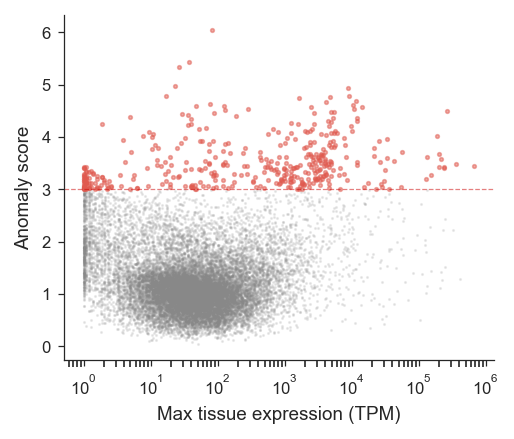

In [3]:
fig, ax = plt.subplots(figsize=FIG_SINGLE, facecolor='white')

valid = gf_annot.dropna(subset=['max_tpm'])
outlier_mask = valid['anomaly_score'] > 3

# Plot on log10 scale; +1 offset handles TPM=0
tpm_plot = valid['max_tpm'] + 1

# Background genes
ax.scatter(tpm_plot[~outlier_mask], valid.loc[~outlier_mask, 'anomaly_score'],
           s=0.5, alpha=0.15, color=NEUTRAL_COLOR, rasterized=True)
# Outliers
ax.scatter(tpm_plot[outlier_mask], valid.loc[outlier_mask, 'anomaly_score'],
           s=3, alpha=0.5, color=GLITCH_COLOR)
ax.axhline(3.0, color='#CC0000', linestyle='--', linewidth=0.6, alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('Max tissue expression (TPM)')
ax.set_ylabel('Anomaly score')

sns.despine()
fig.tight_layout()
save_fig(fig, 'Fig3a_expression_vs_anomaly')
plt.show()


## Fig 3b — Architecture-specific outlier characterisation

/var/folders/j6/6pz4l2t10238hsq7sl5n5qww0000gn/T/ipykernel_78522/1108604484.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups, rotation=30, ha='right')
/var/folders/j6/6pz4l2t10238hsq7sl5n5qww0000gn/T/ipykernel_78522/1108604484.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups, rotation=30, ha='right')
/var/folders/j6/6pz4l2t10238hsq7sl5n5qww0000gn/T/ipykernel_78522/1108604484.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(groups, rotation=30, ha='right')


Saved: figs/Fig3b_architecture_specific_outliers.pdf, figs/Fig3b_architecture_specific_outliers.png


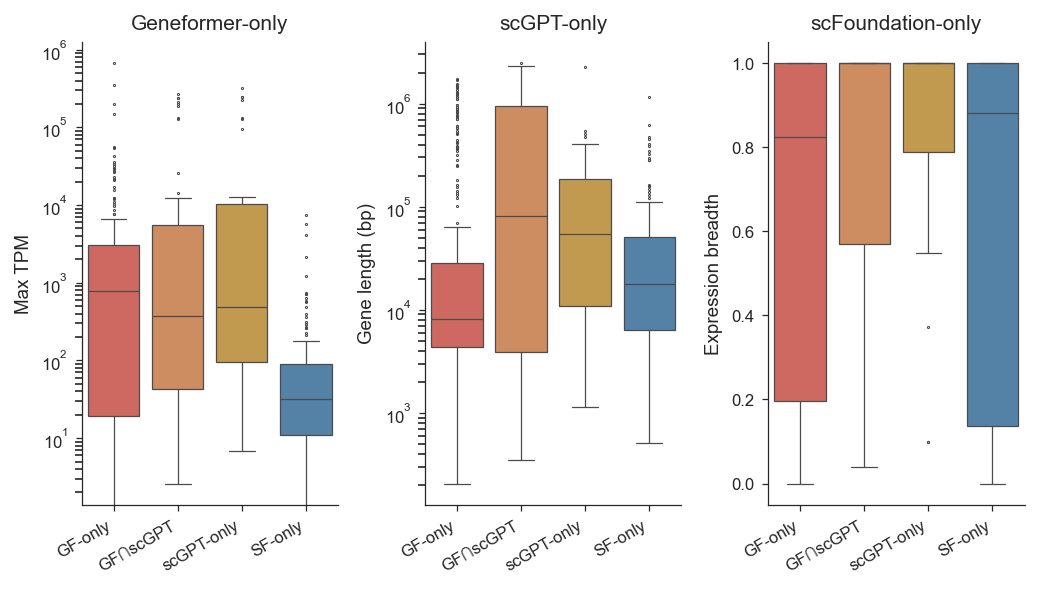

In [4]:
# Box plots comparing GF-only, scGPT-only, SF-only outlier properties
groups = ['GF-only', 'GF∩scGPT', 'scGPT-only', 'SF-only']
group_colors = [GLITCH_COLOR, '#E08A4F', '#D4A03C', CONTROL_COLOR]

# Panel titles for each metric
panel_titles = ['Geneformer-only', 'scGPT-only', 'scFoundation-only']

fig, axes = plt.subplots(1, 3, figsize=FIG_DOUBLE, facecolor='white')

for ax, metric, ylabel, title in zip(axes,
    ['max_tpm', 'gene_length_bp', 'expression_breadth'],
    ['Max TPM', 'Gene length (bp)', 'Expression breadth'],
    panel_titles):

    plot_data = cm[cm['outlier_set'].isin(groups)].dropna(subset=[metric])
    if len(plot_data) > 0:
        sns.boxplot(data=plot_data, x='outlier_set', y=metric,
                    order=groups, palette=dict(zip(groups, group_colors)),
                    ax=ax, fliersize=0.5, linewidth=0.6)
        ax.set_title(title)
        ax.set_xlabel('')
        ax.set_ylabel(ylabel)
        ax.set_xticklabels(groups, rotation=30, ha='right')
        if metric in ['max_tpm', 'gene_length_bp']:
            ax.set_yscale('log')

sns.despine()
fig.tight_layout()
save_fig(fig, 'Fig3b_architecture_specific_outliers')
plt.show()


## Fig 3c — Three-model enrichment comparison

Geneformer: 3/4 tests show >1.5x enrichment over background
scGPT: 4/4 tests show >1.5x enrichment over background
scFoundation: 0/4 tests show >1.5x enrichment over background


Saved: figs/Fig3c_enrichment_comparison.pdf, figs/Fig3c_enrichment_comparison.png


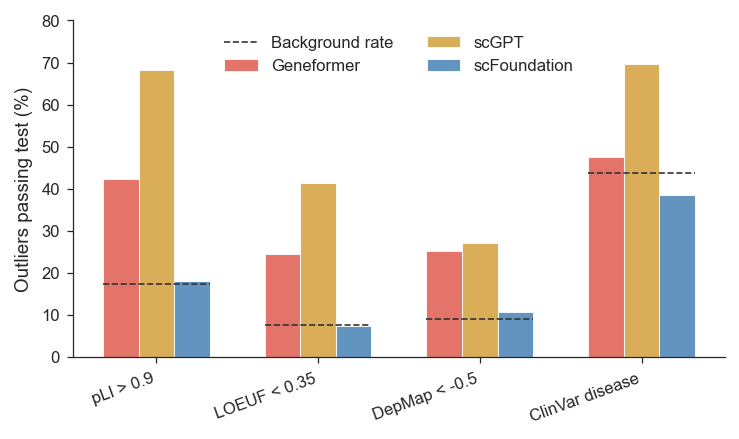

In [5]:
# ── Compute enrichment rates per model from shared-vocabulary data ──
tests = {
    'pLI > 0.9':       ('pLI',          lambda df: df['pLI'] > 0.9),
    'LOEUF < 0.35':    ('LOEUF',        lambda df: df['LOEUF'] < 0.35),
    'DepMap < -0.5':   ('mean_dep',     lambda df: df['mean_dep'] < -0.5),  # column name in P05 CSV
    'ClinVar disease': ('disease_gene', lambda df: df['disease_gene'].astype(bool)),
}

models = [
    ('Geneformer',    'is_gf_outlier', GLITCH_COLOR),
    ('scGPT',         'is_sc_outlier', '#D4A03C'),
    ('scFoundation',  'is_sf_outlier', CONTROL_COLOR),
]

# Background rate (genes not outlier in any model)
bg_rates = {}
for test_name, (col, test_fn) in tests.items():
    valid = cm.dropna(subset=[col])
    all_non = valid[~(valid['is_gf_outlier'] | valid['is_sc_outlier'] | valid['is_sf_outlier'])]
    bg_rates[test_name] = test_fn(all_non).mean() * 100

# Enrichment rates per model
test_names = list(tests.keys())
n_tests = len(test_names)
n_models = len(models)

rates = np.zeros((n_models, n_tests))
for i, (model_name, outlier_col, _) in enumerate(models):
    for j, (test_name, (col, test_fn)) in enumerate(tests.items()):
        valid = cm.dropna(subset=[col])
        outliers = valid[valid[outlier_col]]
        rates[i, j] = test_fn(outliers).mean() * 100

# Print summary
for i, (m, _, _) in enumerate(models):
    sig = sum(1 for j in range(n_tests) if rates[i, j] > bg_rates[test_names[j]] * 1.5)
    print(f'{m}: {sig}/{n_tests} tests show >1.5x enrichment over background')

# ── Grouped bar chart ──
fig, ax = plt.subplots(figsize=(5, 3.0), facecolor='white')
x = np.arange(n_tests)
width = 0.22
offsets = [-width, 0, width]

for i, (model_name, _, color) in enumerate(models):
    ax.bar(x + offsets[i], rates[i], width, color=color, alpha=0.85,
           edgecolor='white', linewidth=0.5, label=model_name)

# Background rate markers (dashed line spanning each test group)
for j, test_name in enumerate(test_names):
    ax.plot([x[j] - 1.5*width, x[j] + 1.5*width],
            [bg_rates[test_name], bg_rates[test_name]],
            color='#333333', linewidth=0.8, linestyle='--', zorder=3)

ax.plot([], [], color='#333333', linewidth=0.8, linestyle='--', label='Background rate')

ax.set_xticks(x)
ax.set_xticklabels(test_names, rotation=20, ha='right')
ax.set_ylabel('Outliers passing test (%)')
ax.legend(loc='upper center', ncol=2)
ax.set_ylim(0, max(rates.max(), max(bg_rates.values())) * 1.15)

sns.despine()
fig.tight_layout()
save_fig(fig, 'Fig3c_enrichment_comparison')
plt.show()


## Supplementary Figure S3 — Gene length and expression breadth

Three-panel descriptive overview of Geneformer outlier genes:
gene length distribution, expression breadth distribution, and
anomaly score versus expression breadth.

Saved: figs/figS3_descriptive_overview.pdf, figs/figS3_descriptive_overview.png


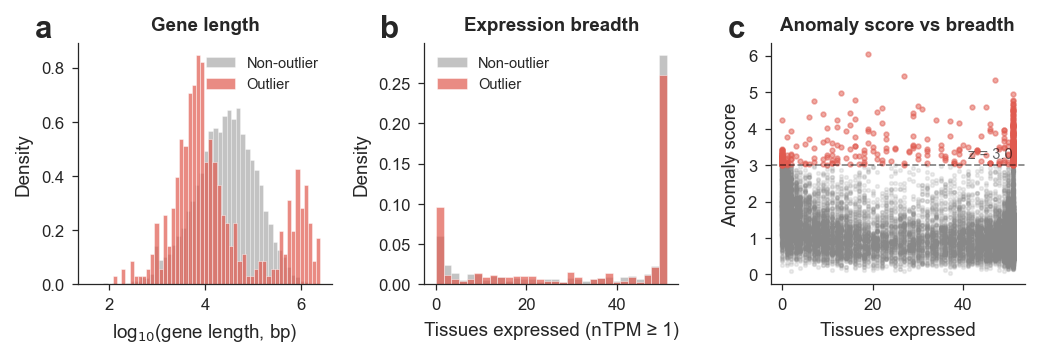

In [6]:
# Fig S3: Gene length and expression breadth of outlier genes

outlier = gf_annot[gf_annot['is_glitch'] == True]
normal = gf_annot[gf_annot['is_glitch'] == False]
ANOMALY_THRESHOLD = 3.0

fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.5))

# (a) Gene length distribution
ax = axes[0]
for label, grp, color, alpha in [('Non-outlier', normal, NEUTRAL_COLOR, 0.5),
                                   ('Outlier', outlier, GLITCH_COLOR, 0.7)]:
    vals = np.log10(grp['gene_length_bp'].dropna() + 1)
    ax.hist(vals, bins=50, alpha=alpha, label=label, color=color, density=True,
            edgecolor='white', linewidth=0.3)
ax.set_xlabel('log$_{10}$(gene length, bp)', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.set_title('Gene length', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, framealpha=0.8)
ax.tick_params(labelsize=8)

# (b) Expression breadth distribution
ax = axes[1]
for label, grp, color, alpha in [('Non-outlier', normal, NEUTRAL_COLOR, 0.5),
                                   ('Outlier', outlier, GLITCH_COLOR, 0.7)]:
    vals = grp['n_tissues_expressed'].dropna()
    ax.hist(vals, bins=30, alpha=alpha, label=label, color=color, density=True,
            edgecolor='white', linewidth=0.3)
ax.set_xlabel('Tissues expressed (nTPM ≥ 1)', fontsize=9)
ax.set_ylabel('Density', fontsize=9)
ax.set_title('Expression breadth', fontsize=9, fontweight='bold')
ax.legend(fontsize=7, framealpha=0.8)
ax.tick_params(labelsize=8)

# (c) Anomaly score vs expression breadth
ax = axes[2]
n_mask = gf_annot['is_glitch'] == False
o_mask = gf_annot['is_glitch'] == True
ax.scatter(gf_annot.loc[n_mask, 'n_tissues_expressed'],
           gf_annot.loc[n_mask, 'anomaly_score_with_isolation'],
           s=3, alpha=0.15, color=NEUTRAL_COLOR, rasterized=True, zorder=1)
ax.scatter(gf_annot.loc[o_mask, 'n_tissues_expressed'],
           gf_annot.loc[o_mask, 'anomaly_score_with_isolation'],
           s=5, alpha=0.5, color=GLITCH_COLOR, rasterized=True, zorder=2)
ax.axhline(ANOMALY_THRESHOLD, color='black', ls='--', lw=0.8, alpha=0.5)
ax.text(51, ANOMALY_THRESHOLD + 0.1, f'z = {ANOMALY_THRESHOLD}', fontsize=7,
        ha='right', va='bottom', color='black', alpha=0.6)
ax.set_xlabel('Tissues expressed', fontsize=9)
ax.set_ylabel('Anomaly score', fontsize=9)
ax.set_title('Anomaly score vs breadth', fontsize=9, fontweight='bold')
ax.tick_params(labelsize=8)

for i, (ax, lbl) in enumerate(zip(axes, 'abc')):
    ax.text(-0.10, 1.12, lbl, transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right',
            fontfamily='sans-serif')

sns.despine()
fig.tight_layout()
save_fig(fig, 'figS3_descriptive_overview')
plt.show()